# Souvenir Sales - Time Series Analysis

The following is a statistical analysis on a monthly time series which collects data about the sales of a souvenir shop in Australia in the period between 1987 and 1992.

The analysis will roughly follow the Box-Jenkins method and will focus on reaching stationarity for the time series, estimating a SARIMA model and predicting future values.

## Data exploration

In [8]:
library(tidyverse)
library(tsdl)
library(tseries)
library(tsibble)
library(feasts)
library(forecast)
library(lmtest)
library(ldsr)

In [9]:
data <- subset(tsdl, 12, "sales", description = "Queensland")[[1]]
attributes(data)

$tsp
[1] 1987.000 1993.917   12.000

$class
[1] "ts"

$source
[1] "Makridakis, Wheelwright and Hyndman (1998)"

$description
[1] "Monthly sales for a souvenir shop on the wharf at a beach resort town in Queensland, Australia. Jan 1987-Dec 1993"

$subject
[1] "Sales"

Now that we have imported the time series, let's have a first look at its values.

In [10]:
tseries <- data %>% as_tsibble() %>% head(n = 72) %>%
  rename(date = index, sales = value)
tseries

date,sales
<mth>,<dbl>
1987 gen,1664.81
1987 feb,2397.53
1987 mar,2840.71
1987 apr,3547.29
1987 mag,3752.96
1987 giu,3714.74
1987 lug,4349.61
1987 ago,3566.34
1987 set,5021.82


## Check for non-stationarity

Let's make a plot and see what we can say about it.

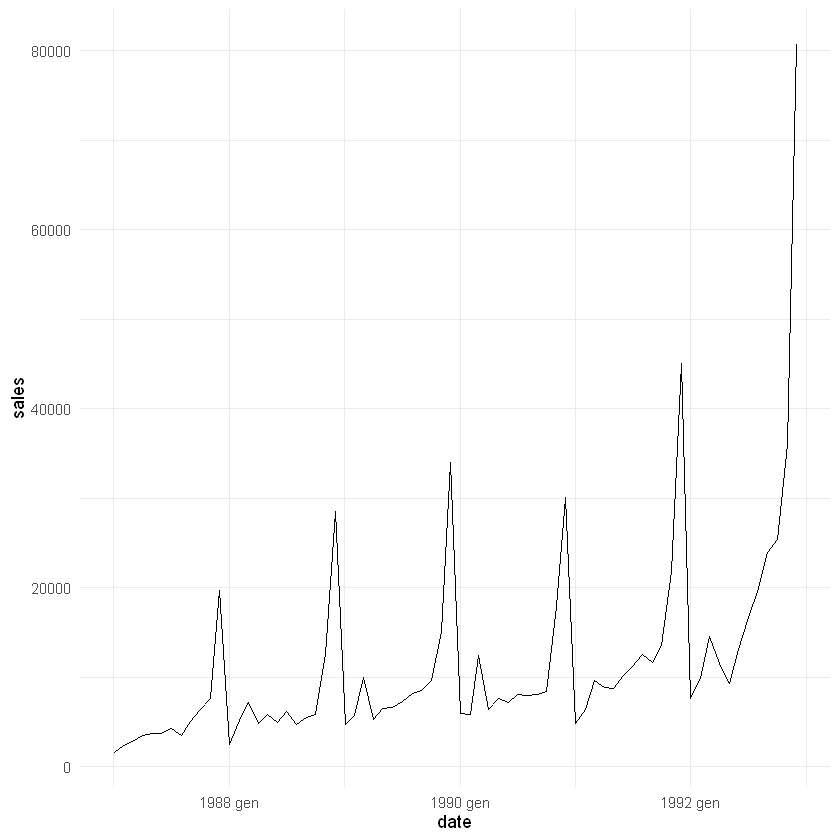

In [11]:
tseries %>% ggplot(aes(x = date, y = sales)) +
  geom_line() +
  theme_minimal()

From the plot of the series, we can already grasp that it is not stationary, as the expected value is not constant over time and neither is variance, which tends to increase. In particular, we can speculate the presence of an upward trend and a seasonal effect, which is comprehensible, considering the tourist vocation of the shop.

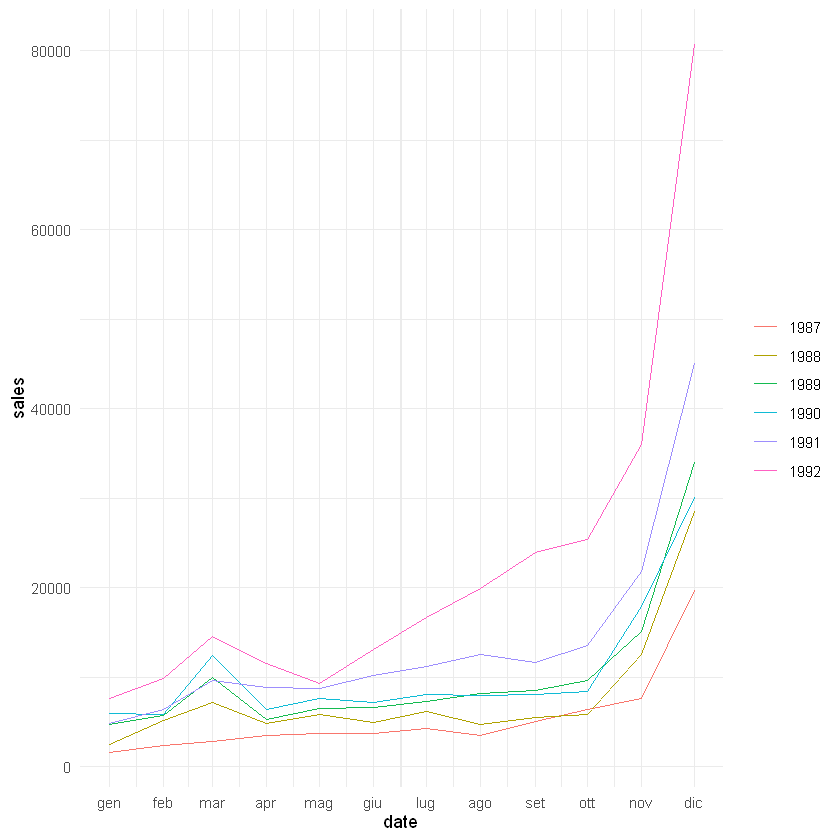

In [12]:
tseries %>% gg_season(sales) +
  theme_minimal()

To better appreciate it, this plot shows the data for each year separately. The values of the series are clearly higher for the latest years and there is a recurring peak in the months of March and August, followed by a valley in October.

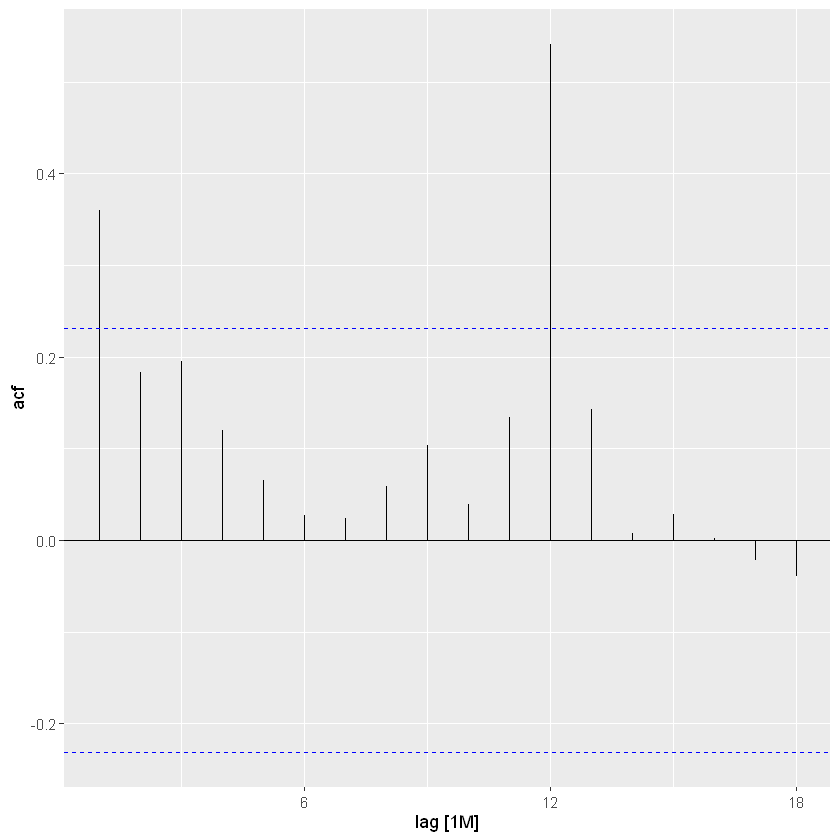

In [13]:
tseries %>% ACF(sales) %>% autoplot()

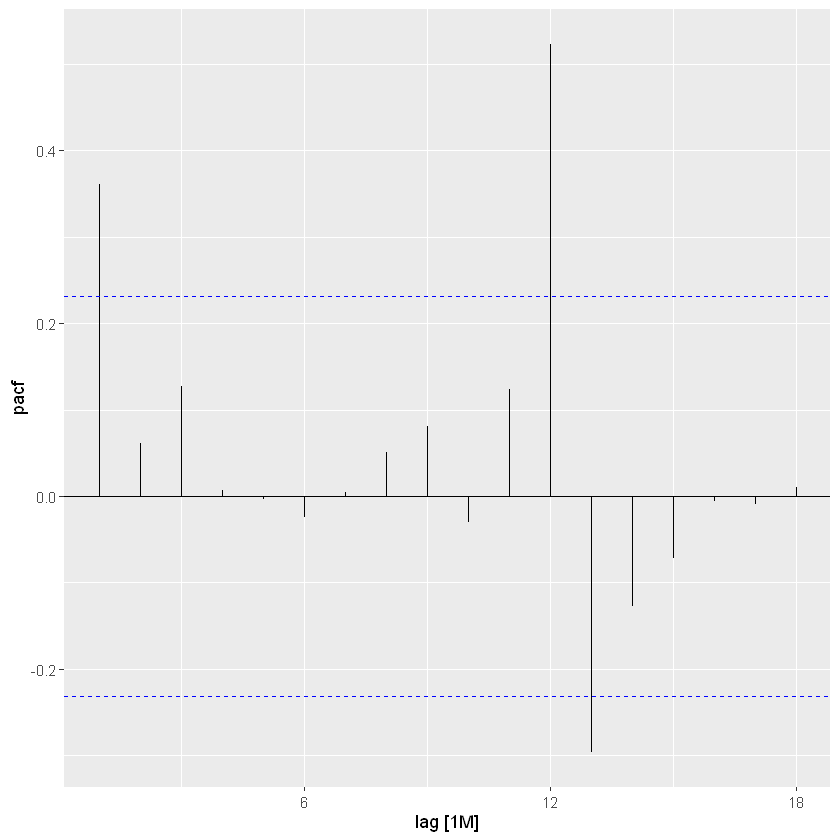

In [14]:
tseries %>% PACF(sales) %>% autoplot()

Lastly, these are the *global* and *partial autocorrelation functions* for the series. The slow decay for the ACF suggests, once again, the existence of a trend, while the spikes at lag 12 indicate a probable seasonality.

To formalize our guesses, let's resort to two statistical test:
- The **Augmented Dickey-Fuller test** tests the null hypothesis of the presence of a unit root in our time series
- The **KPSS test** tests the null hypothesis that our data is stationary

In [15]:
tseries %>% as.ts() %>% adf.test()


	Augmented Dickey-Fuller Test

data:  .
Dickey-Fuller = -1.2891, Lag order = 4, p-value = 0.8648
alternative hypothesis: stationary


In [16]:
tseries %>% as.ts() %>% kpss.test()

Warning message in kpss.test(.):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  .
KPSS Level = 0.98879, Truncation lag parameter = 3, p-value = 0.01


We were expecting to reject H0 for **KPSS** and not be able to reject it for **ADF** and that's exactly what happened, looking at the p-values.

## Reach stationarity

In order to obtain stationarity in our time series, we need to perform a series of operations: we are going to stabilize the variance through the *Box-Cox transformation* and then apply differencing to treat trend and seasonality.

In [17]:
lambda <- BoxCox.lambda(tseries$sales)
bc <- BoxCox(tseries$sales, lambda = lambda)
tseries.novar <- tseries %>% mutate(sales = bc)

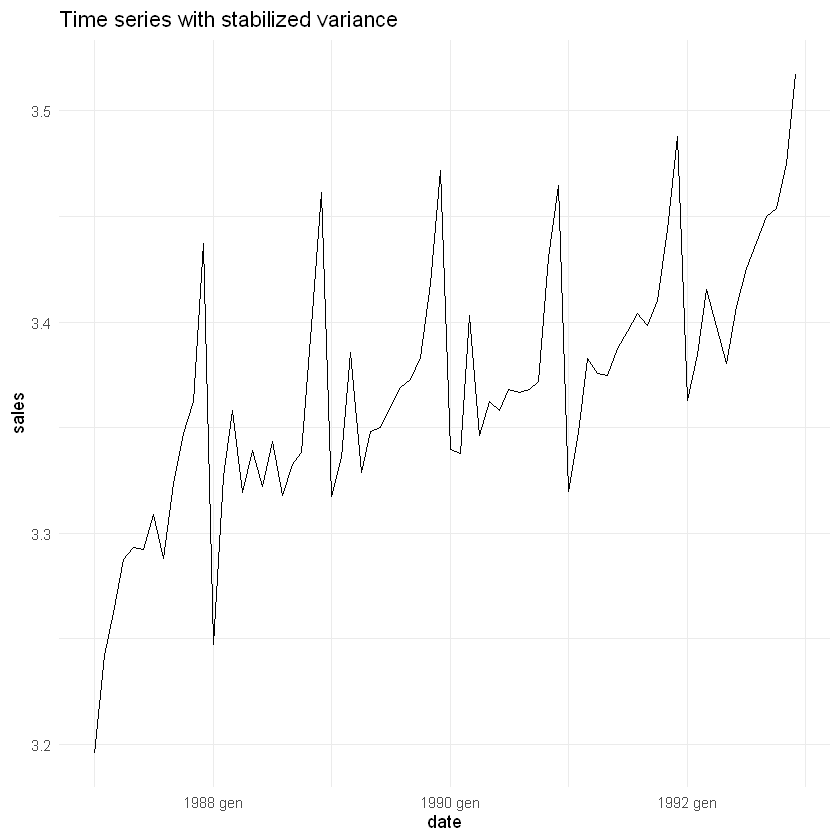

In [18]:
tseries.novar %>% ggplot(aes(x = date, y = sales)) +
  geom_line() +
  theme_minimal() +
  ggtitle("Time series with stabilized variance")

In [19]:
tseries.diff <- tseries.novar %>%
  mutate(date = date, sales = difference(sales, lag = 1, differences = 1)) %>%
  slice_tail(n = -1)
tseries.diff

date,sales
<mth>,<dbl>
1987 feb,0.046526525
1987 mar,0.020119305
1987 apr,0.024987935
1987 mag,0.006104526
1987 giu,-0.001101775
1987 lug,0.016647582
1987 ago,-0.021066208
1987 set,0.035621966
1987 ott,0.023653780


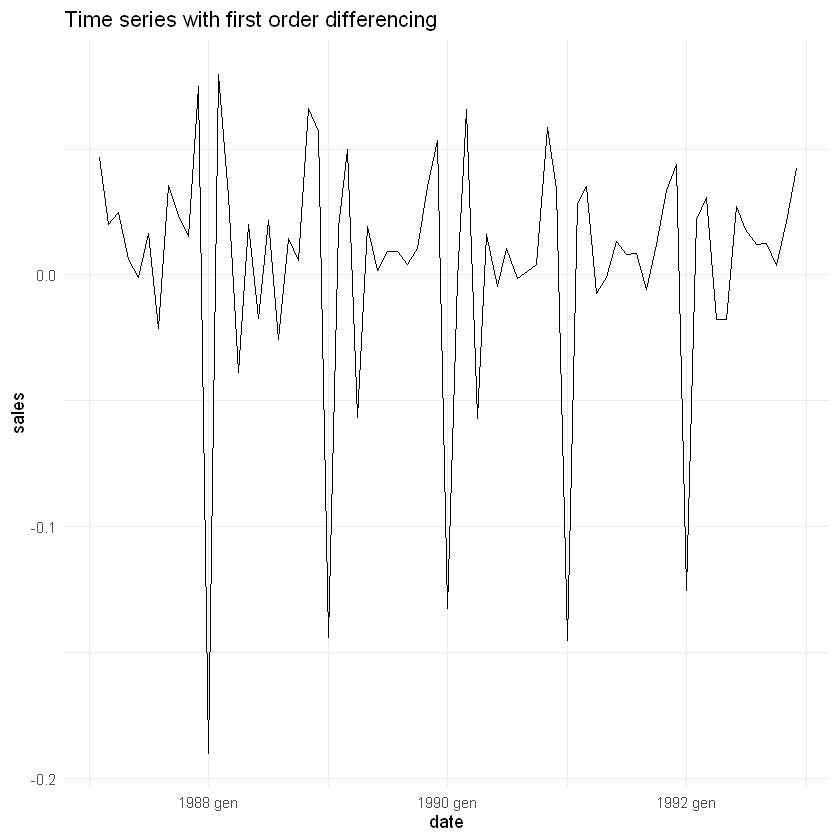

In [20]:
tseries.diff %>%
  ggplot(aes(x = date, y = sales)) +
  geom_line() +
  theme_minimal() +
  ggtitle("Time series with first order differencing")

The first order differencing removes trend, but leaves seasonality.

In [21]:
tseries.diff.s <- tseries.novar %>%
  mutate(sales = difference(sales, lag = 12, differences = 1)) %>%
  slice_tail(n= -12)
tseries.diff.s

date,sales
<mth>,<dbl>
1988 gen,0.051568020
1988 feb,0.084726930
1988 mar,0.095603349
1988 apr,0.031817401
1988 mag,0.045779040
1988 giu,0.029796718
1988 lug,0.034586760
1988 ago,0.030098278
1988 set,0.008861153


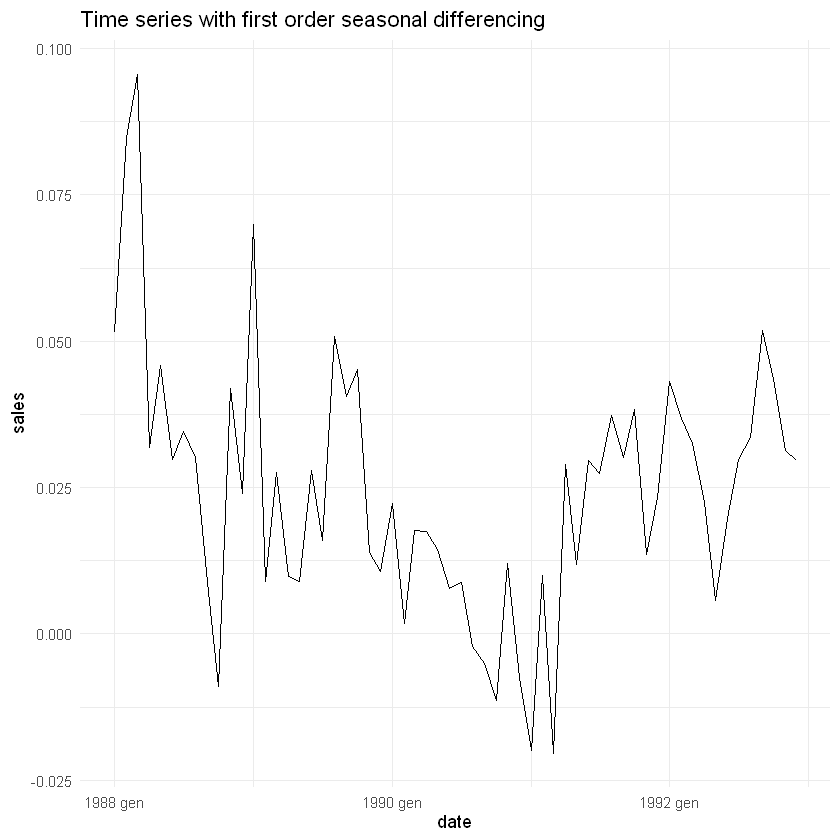

In [22]:
tseries.diff.s %>%
  ggplot(aes(x = date, y = sales)) +
  geom_line() +
  theme_minimal() +
  ggtitle("Time series with first order seasonal differencing")

The seasonal differencing removes seasonality, but leaves trend.

In [23]:
tseries.diff.final <- tseries.novar %>%
  mutate(sales = difference(sales, lag = 1, differences = 1)) %>%
  slice_tail(n = -1) %>%
  mutate(sales = difference(sales, lag = 12, differences = 1)) %>%
  slice_tail (n = -12)
tseries.diff.final

date,sales
<mth>,<dbl>
1988 feb,0.0331589098
1988 mar,0.0108764194
1988 apr,-0.0637859486
1988 mag,0.0139616395
1988 giu,-0.0159823221
1988 lug,0.0047900423
1988 ago,-0.0044884824
1988 set,-0.0212371251
1988 ott,-0.0179049366


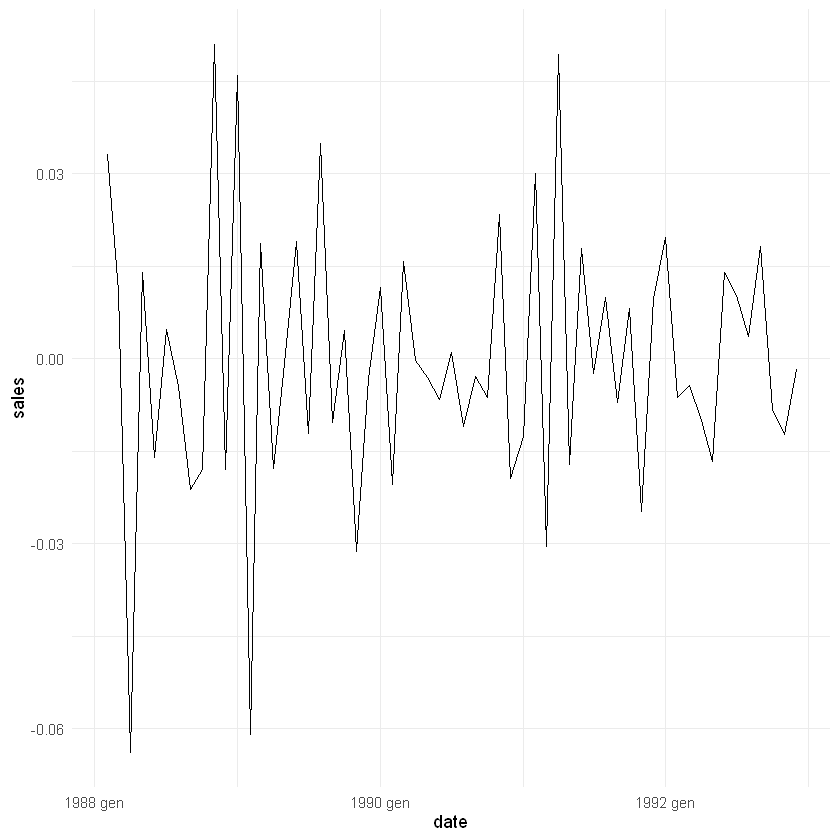

In [24]:
tseries.diff.final %>%
  ggplot(aes(x = date, y = sales)) +
  geom_line() +
  theme_minimal()

The new series should be stationary now. Let's check with our two tests.

In [25]:
tseries.diff.final %>% as.ts() %>% adf.test()

Warning message in adf.test(.):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  .
Dickey-Fuller = -6.0066, Lag order = 3, p-value = 0.01
alternative hypothesis: stationary


In [26]:
tseries.diff.final %>% as.ts() %>% kpss.test()

Warning message in kpss.test(.):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  .
KPSS Level = 0.068468, Truncation lag parameter = 3, p-value = 0.1


Our conclusions on the null hypothesis have now switched, as we expected.

Let's look at the ACF and PACF.

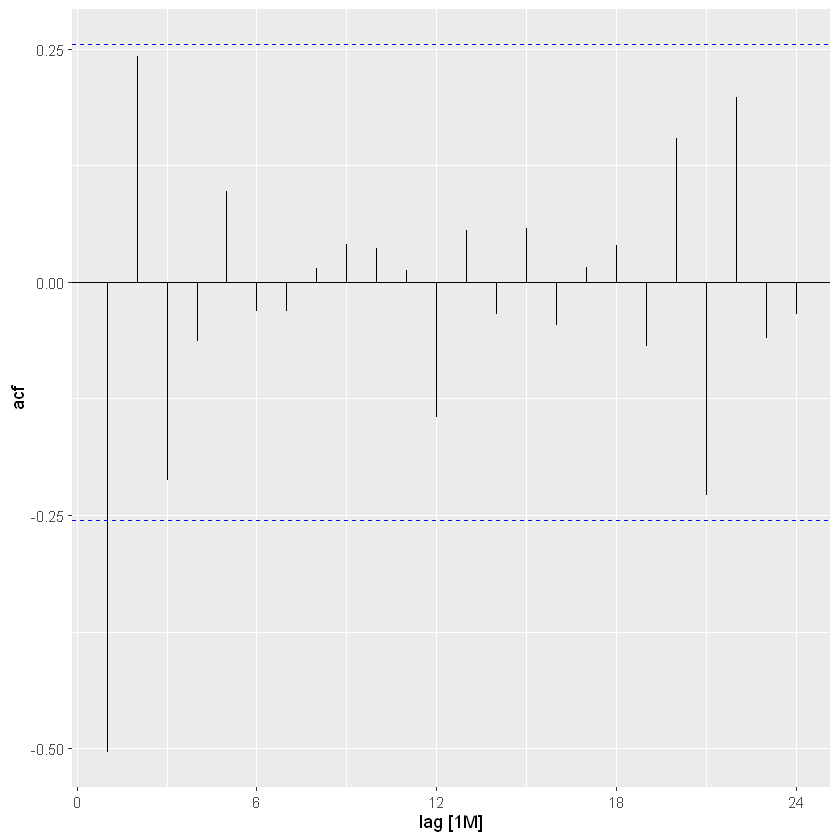

In [27]:
tseries.diff.final %>% ACF(sales, lag_max = 24) %>% autoplot()

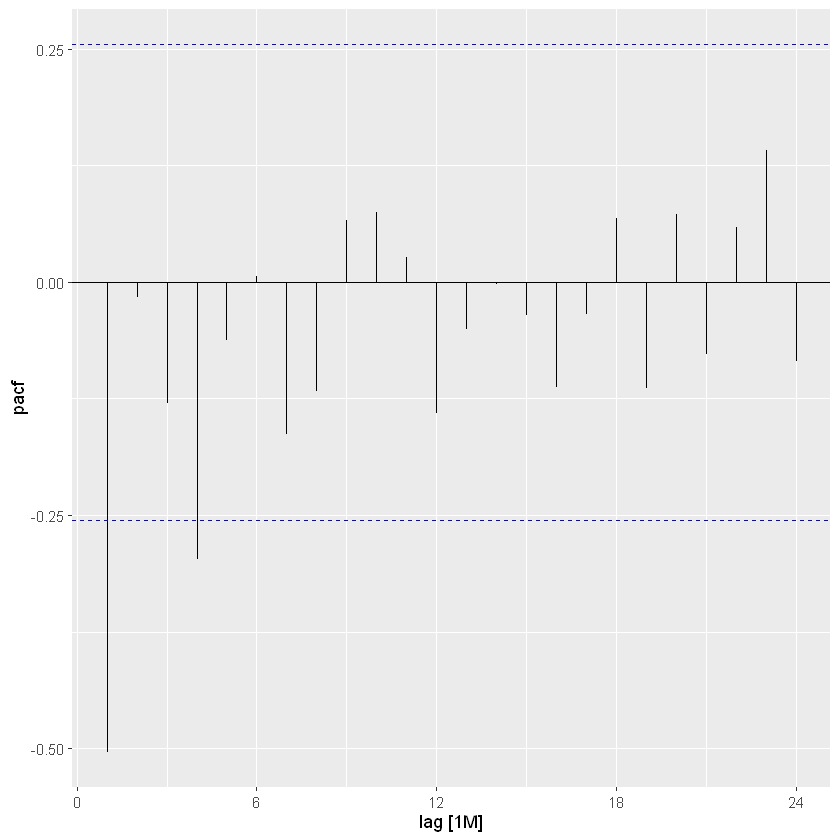

In [28]:
tseries.diff.final %>% PACF(sales, lag_max = 24) %>% autoplot()

## Estimate ARIMA model

At this point, we should be able to estimate the values for the parameters of our ARIMA model by looking at these two plots and the spikes in them. However, the most reliable way to actually determine the parameters is using an objective procedure, for example a stepwise-like, and let a computer do it for us by choosing among many ARIMA models the "best" one, in terms of optimizing a certain indicator.

In [29]:
fit <- tseries %>%
  as.ts() %>%
  auto.arima(start.p = 1,start.q = 1, max.p = 3, max.q = 3,
             start.P = 0, seasonal = T, d = 1, D = 1, trace = T,
             stepwise = T, lambda = "auto")


 ARIMA(1,1,1)(0,1,1)[12]                    : -3.783953
 ARIMA(0,1,0)(0,1,0)[12]                    : 12.95279
 ARIMA(1,1,0)(1,1,0)[12]                    : -3.506572
 ARIMA(0,1,1)(0,1,1)[12]                    : -4.677704
 ARIMA(0,1,1)(0,1,0)[12]                    : -1.072194
 ARIMA(0,1,1)(1,1,1)[12]                    : Inf
 ARIMA(0,1,1)(0,1,2)[12]                    : Inf
 ARIMA(0,1,1)(1,1,0)[12]                    : -2.863223
 ARIMA(0,1,1)(1,1,2)[12]                    : Inf
 ARIMA(0,1,0)(0,1,1)[12]                    : 11.30466
 ARIMA(0,1,2)(0,1,1)[12]                    : -2.804183
 ARIMA(1,1,0)(0,1,1)[12]                    : -5.843042
 ARIMA(1,1,0)(0,1,0)[12]                    : -0.9084839
 ARIMA(1,1,0)(1,1,1)[12]                    : Inf
 ARIMA(1,1,0)(0,1,2)[12]                    : -4.464014
 ARIMA(1,1,0)(1,1,2)[12]                    : Inf
 ARIMA(2,1,0)(0,1,1)[12]                    : -3.737659
 ARIMA(2,1,1)(0,1,1)[12]                    : -1.63897

 Best model: ARIMA(1,1

In [30]:
coeftest(fit)


z test of coefficients:

     Estimate Std. Error z value  Pr(>|z|)    
ar1  -0.52834    0.10898 -4.8480 1.247e-06 ***
sma1 -0.57352    0.22209 -2.5824  0.009812 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


The chosen model appears to be *ARIMA(1,1,0)(0,1,1)[12]*. Along with it, we have also got a number of diagnostic tools: we can see that the parameters are significantly different than 0.

Let's look at other diagnostic measures through some plots.


	Ljung-Box test

data:  Residuals from ARIMA(1,1,0)(0,1,1)[12]
Q* = 10.467, df = 12, p-value = 0.575

Model df: 2.   Total lags used: 14



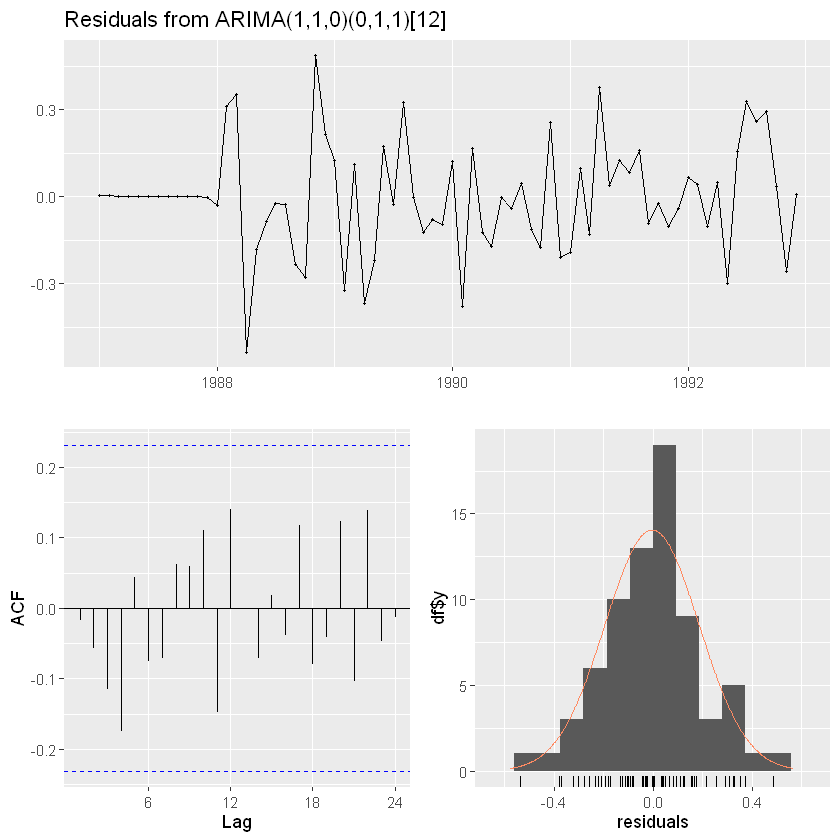

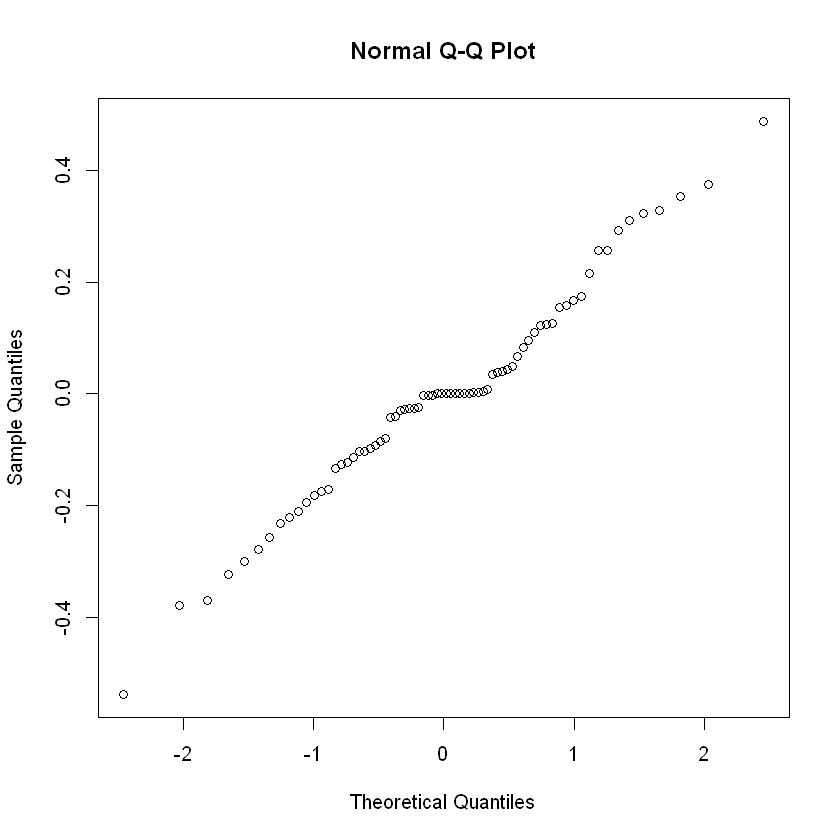

In [31]:
checkresiduals(fit)
qqnorm(fit$residuals)

The residuals roughly follow a normal distribution, as deduced from the histogram and the Q-Q plot, but they seem to follow a pattern in their time series, which is not good for our model.

## Forecast

For the last step, let's try to forecast some future values, in particular 12 more observations, and plot the result.

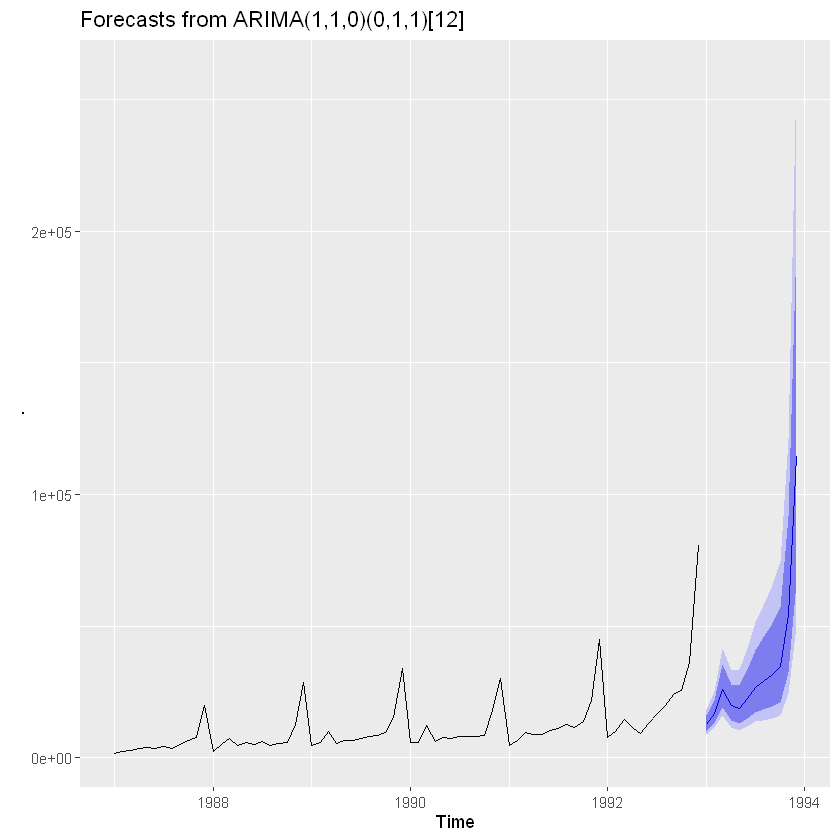

In [32]:
tseries.forecast <- forecast(fit, h = 12)
tseries.forecast %>% autoplot()